# Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    make_scorer
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
df = pd.read_csv('/content/Employee Attrition.csv')

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


# Step 2: Dataset Verification

In [ ]:
print("Dataset Verification")
print("=" * 60)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nAll Dataset Columns:")
print(df.columns.tolist())

Dataset Verification
Number of Rows: 59598
Number of Columns: 24

All Dataset Columns:
['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


# Step 3: Feature and Target Separation

In [ ]:
X = df.drop(columns=['Employee ID', 'Attrition'])
y = df['Attrition']

print("Feature and Target Separation")
print("=" * 60)

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Values:")
print(y.unique())

Feature and Target Separation
Feature Shape: (59598, 22)
Target Shape : (59598,)

Feature Columns:
['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Target Values:
['Stayed' 'Left']


# Step 4: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Train-Test Split Completed")
print("=" * 60)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape :", X_test.shape)
print("Training Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Train-Test Split Completed
Training Feature Shape: (47678, 22)
Testing Feature Shape : (11920, 22)
Training Target Shape : (47678,)
Testing Target Shape  : (11920,)

Training Target Distribution:
Attrition
Stayed    25008
Left      22670
Name: count, dtype: int64

Testing Target Distribution:
Attrition
Stayed    6252
Left      5668
Name: count, dtype: int64


# Step 5: Identify Numerical and Categorical Features

In [ ]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical and Categorical Features")
print("=" * 60)

print("\nNumerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:", len(numerical_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

Numerical and Categorical Features

Numerical Features:
['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

Number of Numerical Features: 7

Categorical Features:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Number of Categorical Features: 15


# Step 6: Preprocessing Pipeline

In [ ]:
numerical_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

preprocessor_gb = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Gradient Boosting Preprocessing Pipeline Created Successfully")
print("=" * 60)
print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

Gradient Boosting Preprocessing Pipeline Created Successfully
Numerical Features: 7
Categorical Features: 15


# Step 7: Baseline Gradient Boosting Model

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

baseline_gb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_gb),
        ('gb', gb_model)
    ]
)

print("Baseline Gradient Boosting Pipeline Created Successfully")
print("=" * 60)
print("Model: Gradient Boosting Classifier")
print("Number of Trees:", 100)
print("Learning Rate:", 0.1)
print("Maximum Depth:", 3)
print("Random State:", 42)

Baseline Gradient Boosting Pipeline Created Successfully
Model: Gradient Boosting Classifier
Number of Trees: 100
Learning Rate: 0.1
Maximum Depth: 3
Random State: 42


# Step 8: Train Baseline Model

In [ ]:
baseline_gb_pipeline.fit(X_train, y_train)

print("Baseline Gradient Boosting Model Trained Successfully")

Baseline Gradient Boosting Model Trained Successfully


# Step 9: Baseline Predictions

In [ ]:
y_pred_baseline_gb = baseline_gb_pipeline.predict(X_test)

print("Baseline Gradient Boosting Predictions Generated Successfully")
print("=" * 60)

print("Number of Predictions:", len(y_pred_baseline_gb))

print("\nFirst 20 Predictions:")
print(y_pred_baseline_gb[:20])

Baseline Gradient Boosting Predictions Generated Successfully
Number of Predictions: 11920

First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']


# Step 10: Baseline Model Evaluation Performance

In [ ]:
accuracy_baseline_gb = accuracy_score(y_test, y_pred_baseline_gb)
precision_baseline_gb = precision_score(y_test, y_pred_baseline_gb, pos_label='Left')
recall_baseline_gb = recall_score(y_test, y_pred_baseline_gb, pos_label='Left')
f1_baseline_gb = f1_score(y_test, y_pred_baseline_gb, pos_label='Left')

print("Baseline Gradient Boosting Performance")
print("=" * 50)
print(f"Accuracy : {accuracy_baseline_gb:.4f}")
print(f"Precision: {precision_baseline_gb:.4f}")
print(f"Recall   : {recall_baseline_gb:.4f}")
print(f"F1 Score : {f1_baseline_gb:.4f}")

Baseline Gradient Boosting Performance
Accuracy : 0.7607
Precision: 0.7507
Recall   : 0.7438
F1 Score : 0.7473


# Step 11: Baseline Confusion Matrix

In [ ]:
cm_baseline_gb = confusion_matrix(
    y_test,
    y_pred_baseline_gb,
    labels=['Stayed', 'Left']
)

print("Baseline Gradient Boosting Confusion Matrix")
print("=" * 60)
print(cm_baseline_gb)
print("\nTotal samples in confusion matrix:", cm_baseline_gb.sum())

Baseline Gradient Boosting Confusion Matrix
[[4852 1400]
 [1452 4216]]

Total samples in confusion matrix: 11920


# Step 12: Baseline Classification Report

In [ ]:
print("Classification Report - Baseline Gradient Boosting")
print("=" * 60)
print(
    classification_report(y_test, y_pred_baseline_gb,
        labels=['Stayed', 'Left']
    )
);

Classification Report - Baseline Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.77      0.78      0.77      6252
        Left       0.75      0.74      0.75      5668

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



# Step 13: Baseline ROC-AUC

In [ ]:
y_proba_baseline_gb = baseline_gb_pipeline.predict_proba(X_test)[:, 1]

roc_auc_baseline_gb = roc_auc_score(y_test, y_proba_baseline_gb)

print("Baseline Gradient Boosting ROC-AUC")
print("=" * 50)
print(f"ROC-AUC : {roc_auc_baseline_gb:.4f}")

Baseline Gradient Boosting ROC-AUC
ROC-AUC : 0.8474


# Step 14: Hyperparameter Tuning

In [ ]:
param_grid_gb = {
    'gb__n_estimators': [100, 200],
    'gb__learning_rate': [0.05, 0.1],
    'gb__max_depth': [2, 3]
}

print("Gradient Boosting Parameter Grid")
print("=" * 60)

print(param_grid_gb)

Gradient Boosting Parameter Grid
{'gb__n_estimators': [100, 200], 'gb__learning_rate': [0.05, 0.1], 'gb__max_depth': [2, 3]}


# Step 15: Hyperparameter Tuning

In [ ]:
# Create F1 Scorer with Left as Positive Class

f1_left_scorer = make_scorer(
    f1_score,
    pos_label='Left'
)

print("Custom F1 Scorer Created Successfully")
print("=" * 60)

print("Positive Class:", "Left")
print("Scoring Metric:", "F1 Score")

Custom F1 Scorer Created Successfully
Positive Class: Left
Scoring Metric: F1 Score


In [ ]:
print("Training Target Classes")
print("=" * 60)

print("Unique classes:", y_train.unique())
print("\nClass counts:")
print(y_train.value_counts())

Training Target Classes
Unique classes: ['Stayed' 'Left']

Class counts:
Attrition
Stayed    25008
Left      22670
Name: count, dtype: int64


In [ ]:
grid_search_gb = GridSearchCV(
    estimator=baseline_gb_pipeline,
    param_grid=param_grid_gb,
    cv=3,
    scoring=f1_left_scorer,
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

grid_search_gb.fit(X_train, y_train)

print("Gradient Boosting Hyperparameter Tuning Completed")
print("=" * 60)

print("Best Parameters:")
print(grid_search_gb.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid_search_gb.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Gradient Boosting Hyperparameter Tuning Completed
Best Parameters:
{'gb__learning_rate': 0.1, 'gb__max_depth': 2, 'gb__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7436


# Step 16: Tuned Model Ready

In [ ]:
tuned_gb_model = grid_search_gb.best_estimator_

print("Tuned Gradient Boosting Model Ready")
print("=" * 60)
print("Best Parameters:")
print(grid_search_gb.best_params_)

Tuned Gradient Boosting Model Ready
Best Parameters:
{'gb__learning_rate': 0.1, 'gb__max_depth': 2, 'gb__n_estimators': 200}


# Step 17: Tuned Predictions

In [ ]:
y_pred_tuned_gb = tuned_gb_model.predict(X_test)

print("Tuned Gradient Boosting Predictions Generated Successfully")
print("=" * 60)
print("Number of Predictions:", len(y_pred_tuned_gb))
print("\nFirst 20 Predictions:")
print(y_pred_tuned_gb[:20])

Tuned Gradient Boosting Predictions Generated Successfully
Number of Predictions: 11920

First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']


# Step 18: Tuned Model Evaluation Performance

In [ ]:
accuracy_tuned_gb = accuracy_score(y_test, y_pred_tuned_gb)
precision_tuned_gb = precision_score(y_test, y_pred_tuned_gb,pos_label='Left')
recall_tuned_gb = recall_score(y_test, y_pred_tuned_gb, pos_label='Left')
f1_tuned_gb = f1_score(y_test, y_pred_tuned_gb, pos_label='Left')

print("Tuned Gradient Boosting Performance")
print("=" * 50)
print(f"Accuracy : {accuracy_tuned_gb:.4f}")
print(f"Precision: {precision_tuned_gb:.4f}")
print(f"Recall   : {recall_tuned_gb:.4f}")
print(f"F1 Score : {f1_tuned_gb:.4f}")

Tuned Gradient Boosting Performance
Accuracy : 0.7592
Precision: 0.7504
Recall   : 0.7396
F1 Score : 0.7450


# Step 19: Tuned Confusion Matrix

In [ ]:
cm_tuned_gb = confusion_matrix(y_test, y_pred_tuned_gb,
    labels=['Stayed', 'Left']
)

print("Tuned Gradient Boosting Confusion Matrix")
print("=" * 60)
print(cm_tuned_gb)
print("\nTotal samples in confusion matrix:", cm_tuned_gb.sum())

Tuned Gradient Boosting Confusion Matrix
[[4858 1394]
 [1476 4192]]

Total samples in confusion matrix: 11920


# Step 20: Tuned Classification Report

In [ ]:
print("Classification Report - Tuned Gradient Boosting")
print("=" * 60)
print(
    classification_report(
        y_test,
        y_pred_tuned_gb,
        labels=['Stayed', 'Left']
    )
)

Classification Report - Tuned Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.77      0.78      0.77      6252
        Left       0.75      0.74      0.74      5668

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



# Step 21: Tuned ROC-AUC

In [ ]:
y_proba_tuned_gb = tuned_gb_model.predict_proba(X_test)[:, 1]

roc_auc_tuned_gb = roc_auc_score(y_test, y_proba_tuned_gb)

print("Tuned Gradient Boosting ROC-AUC")
print("=" * 50)
print(f"ROC-AUC : {roc_auc_tuned_gb:.4f}")

Tuned Gradient Boosting ROC-AUC
ROC-AUC : 0.8485


# Step 22: Feature Importance

In [ ]:
# Get feature names after preprocessing
feature_names_gb = (
    tuned_gb_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

# Get feature importance from Gradient Boosting
importance_gb = (
    tuned_gb_model
    .named_steps['gb']
    .feature_importances_
)

# Create DataFrame
feature_importance_gb = pd.DataFrame({
    'Feature': feature_names_gb,
    'Importance': importance_gb
})

# Sort by importance
feature_importance_gb = feature_importance_gb.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

print("Gradient Boosting Feature Importance")
print("=" * 60)
print("\nTop 15 Gradient Boosting Features:")
print("=" * 60)
print(feature_importance_gb.head(15).to_string(index=False))

Gradient Boosting Feature Importance

Top 15 Gradient Boosting Features:
                     Feature  Importance
  cat__Marital Status_Single    0.208959
       cat__Job Level_Senior    0.159024
        cat__Job Level_Entry    0.114701
         cat__Remote Work_No    0.074354
        cat__Remote Work_Yes    0.063730
 cat__Work-Life Balance_Fair    0.049351
 cat__Work-Life Balance_Poor    0.048671
   num__Number of Promotions    0.045057
   num__Number of Dependents    0.032212
    cat__Education Level_PhD    0.031753
     num__Distance from Home    0.030245
          cat__Gender_Female    0.021499
       num__Years at Company    0.018305
cat__Company Reputation_Poor    0.015195
cat__Company Reputation_Good    0.015099


# Step 23: Feature Importance Visualization

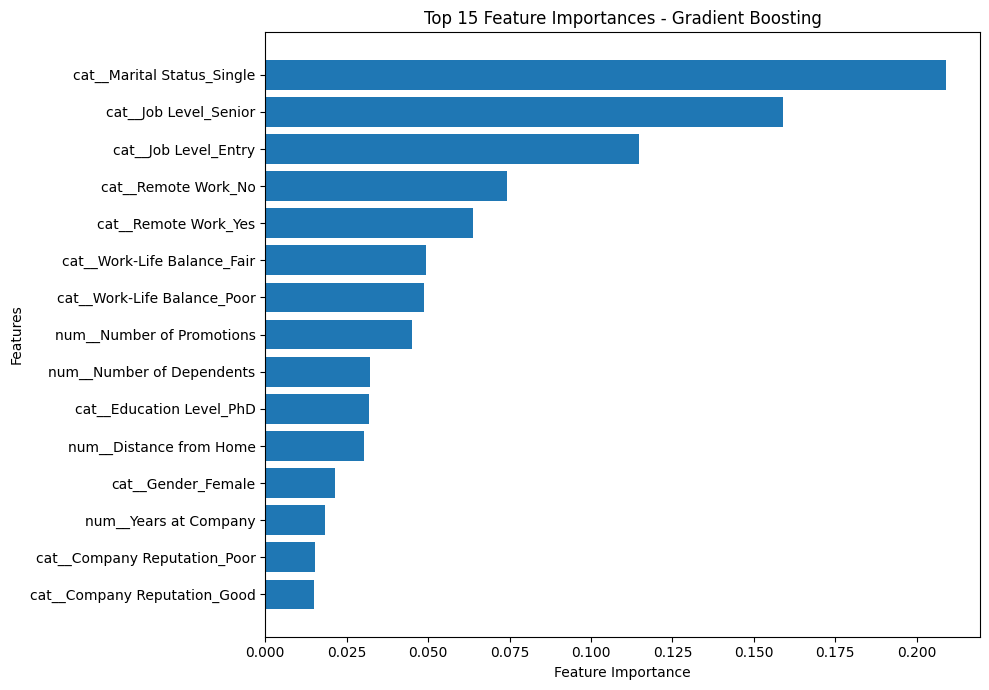

In [ ]:
top_15_gb = feature_importance_gb.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_15_gb['Feature'],
    top_15_gb['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances - Gradient Boosting')
plt.tight_layout()
plt.show()

# Step 24: Baseline vs Tuned Comparison

In [ ]:
gb_comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Left)',
        'Recall (Left)',
        'F1 Score (Left)',
        'ROC-AUC'
    ],
    'Baseline': [
        accuracy_baseline_gb,
        precision_baseline_gb,
        recall_baseline_gb,
        f1_baseline_gb,
        roc_auc_baseline_gb
    ],
    'Tuned': [
        accuracy_tuned_gb,
        precision_tuned_gb,
        recall_tuned_gb,
        f1_tuned_gb,
        roc_auc_tuned_gb
    ]
})

print("Baseline vs Tuned Gradient Boosting")
print("=" * 70)
print(gb_comparison.to_string(index=False))

Baseline vs Tuned Gradient Boosting
          Metric  Baseline    Tuned
        Accuracy  0.760738 0.759228
Precision (Left)  0.750712 0.750448
   Recall (Left)  0.743825 0.739591
 F1 Score (Left)  0.747253 0.744980
         ROC-AUC  0.847371 0.848536


# Step 25: Save Tuned Model

In [ ]:
import joblib

model_filename_gb = "Employee_Attrition_Gradient_Boosting_Model.pkl"
joblib.dump(
    tuned_gb_model,
    model_filename_gb
)

print("Gradient Boosting Model Saved Successfully")
print("=" * 60)
print("File Name:", model_filename_gb)

Gradient Boosting Model Saved Successfully
File Name: Employee_Attrition_Gradient_Boosting_Model.pkl


# Step 26: Load Saved Model

In [ ]:
loaded_gb_model = joblib.load(
    "Employee_Attrition_Gradient_Boosting_Model.pkl"
)

print("Gradient Boosting Model Loaded Successfully")
print("=" * 60)
print(
    "Loaded Model:",
    "Employee_Attrition_Gradient_Boosting_Model.pkl"
)

Gradient Boosting Model Loaded Successfully
Loaded Model: Employee_Attrition_Gradient_Boosting_Model.pkl


# Step 27: Loaded Model Predictions

In [ ]:
y_pred_loaded_gb = loaded_gb_model.predict(X_test)

print("Loaded Gradient Boosting Model Verification")
print("=" * 60)
print("Number of Predictions:", len(y_pred_loaded_gb))
print("\nFirst 20 Predictions:")
print(y_pred_loaded_gb[:20])

Loaded Gradient Boosting Model Verification
Number of Predictions: 11920

First 20 Predictions:
['Left' 'Stayed' 'Left' 'Left' 'Left' 'Stayed' 'Left' 'Left' 'Stayed'
 'Left' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed' 'Stayed'
 'Stayed' 'Left' 'Stayed']


# Step 28: Final Model Verification

In [ ]:
same_predictions_gb = np.array_equal(
    y_pred_tuned_gb,
    y_pred_loaded_gb
)

print("Gradient Boosting Prediction Comparison")
print("=" * 60)
print(
    "Tuned and Loaded Model Predictions:",
    "SAME" if same_predictions_gb else "DIFFERENT"
)

if same_predictions_gb:
    print("Model Verification: PASSED")
else:
    print("Model Verification: FAILED")

Gradient Boosting Prediction Comparison
Tuned and Loaded Model Predictions: SAME
Model Verification: PASSED
